In [1]:
from umap import UMAP
from sklearn.manifold import TSNE, MDS

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

from zadu.measures import class_aware_trustworthiness_continuity

/home/user/Documents/repositories/ais-duomenu-vizualizavimas/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dist_mat = np.load('dist_mat.npy')
labels = np.load('ship-types.npy')
original_data = np.load('original_data.npy')

In [3]:
original_data.shape

(750, 25, 10)

## MDS tyrimas

In [14]:
def plot_mds(
    data,
    original_data,
    labels,
    ax=None,
    random_state=42,
    n_init=4,
    max_iter=300,
    eps=1e-6,
    normalized_stress="auto",
    title="MDS"
):

    embedding = MDS(
        n_components=2,
        metric="precomputed",
        random_state=random_state,
        init="random",
        n_init=n_init,
        max_iter=max_iter,
        eps=eps,
        normalized_stress=normalized_stress
    ).fit_transform(data)

    if ax is None:
        ax = plt.gca()

    sns.scatterplot(
        x=embedding[:, 0],
        y=embedding[:, 1],
        hue=labels,
        palette="tab10",
        s=25,
        alpha=0.8,
        legend=False,
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel("MDS 1")
    ax.set_ylabel("MDS 2")

    original_flat = original_data.reshape(len(original_data), -1)

    trust_scores = []
    cont_scores = []
    knn_scores = []

    for k in range(5, 30):
        ca_tc = class_aware_trustworthiness_continuity.measure(
            original_flat,
            embedding,
            label=labels,
            k=k
        )

        trust_scores.append(
            ca_tc["ca_trustworthiness"] / 25
        )
        cont_scores.append(
            ca_tc["ca_continuity"] / 25
        )

        knn = KNeighborsClassifier(n_neighbors=k)
        knn_scores.append(
            cross_val_score(knn, embedding, labels, cv=5).mean()
        )

    trust_score = float(np.mean(trust_scores))
    cont_score = float(np.mean(cont_scores))
    knn_score = float(np.mean(knn_scores))
    best_k = int(np.argmax(knn_scores) + 5)

    print(
        f"{title} | "
        f"CA Cont {cont_score:.4f} | "
        f"CA Trust {trust_score:.4f} | "
        f"KNN {knn_score:.3f} | "
        f"Geriausias k KNN {best_k}"
    )

    return embedding, {
        "ca_continuity": cont_score,
        "ca_trustworthiness": trust_score,
        "knn_accuracy": knn_score,
        "best_k": best_k
    }


def plot_mds_param(
    param_name,
    param_values,
    distance_matrix,
    original_data,
    labels,
    random_state=42
):
    n = len(param_values)
    cols = min(n, 4)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    default_params = {
        "n_init": 4,
        "max_iter": 300,
        "eps": 1e-6
    }

    results = []

    for i, val in enumerate(param_values):
        params = default_params.copy()
        params[param_name] = val

        _, scores = plot_mds(
            data=distance_matrix,
            original_data=original_data,
            labels=labels,
            ax=axes[i],
            random_state=random_state,
            title=f"{param_name} = {val}",
            **params
        )

        results.append({
            param_name: val,
            **scores
        })

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

    return pd.DataFrame(results)

n_init = 1 | CA Cont 0.0393 | CA Trust 0.0381 | KNN 0.590 | Geriausias k KNN 5
n_init = 4 | CA Cont 0.0393 | CA Trust 0.0380 | KNN 0.599 | Geriausias k KNN 5
n_init = 8 | CA Cont 0.0393 | CA Trust 0.0380 | KNN 0.599 | Geriausias k KNN 5
n_init = 32 | CA Cont 0.0395 | CA Trust 0.0379 | KNN 0.588 | Geriausias k KNN 8


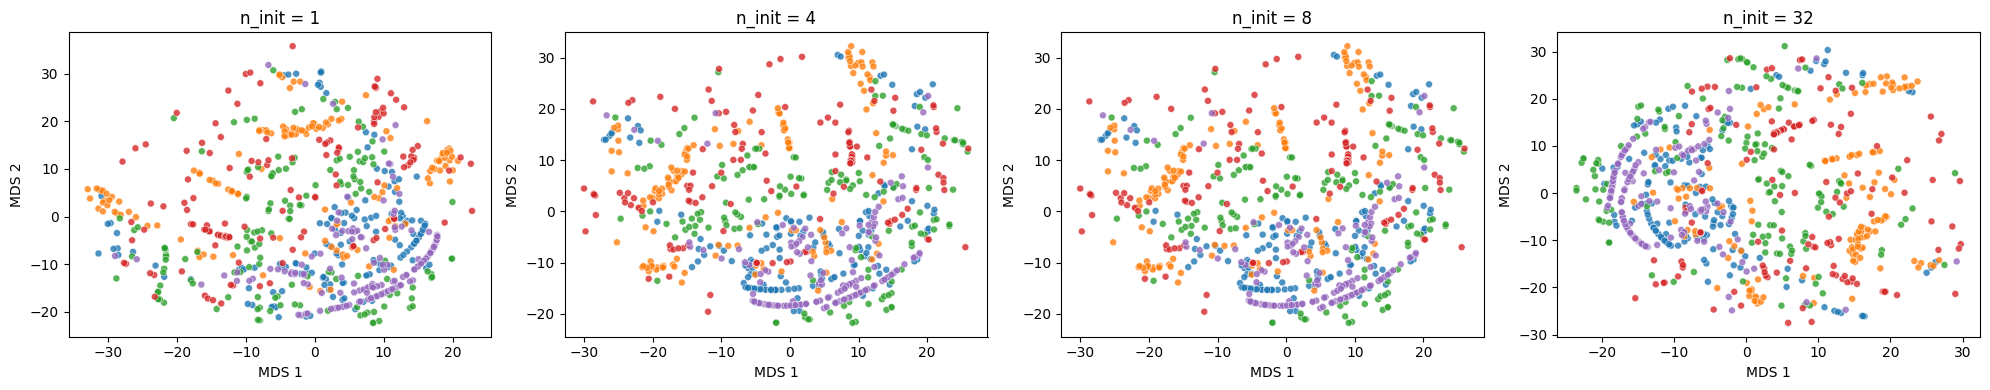

,n_init,ca_continuity,ca_trustworthiness,knn_accuracy,best_k
0,1,0.039307,0.038119,0.590187,5
1,4,0.039343,0.038032,0.598667,5
2,8,0.039343,0.038032,0.598667,5
3,32,0.039472,0.037895,0.588000,8


In [21]:
default_mds_hyperparams = {
    "n_init": [1, 4, 8, 32],
    "max_iter": [25, 50, 200, 400],
    "eps": [1e-3, 1e-4, 1e-5, 1e-6],
}

mds_n_init_results = plot_mds_param(
    param_name="n_init",
    param_values=default_mds_hyperparams["n_init"],
    distance_matrix=dist_mat,
    original_data=original_data,
    labels=labels
)

mds_n_init_results

max_iter = 25 | CA Cont 0.0338 | CA Trust 0.0328 | KNN 0.450 | Geriausias k KNN 11
max_iter = 50 | CA Cont 0.0372 | CA Trust 0.0359 | KNN 0.514 | Geriausias k KNN 7
max_iter = 200 | CA Cont 0.0393 | CA Trust 0.0380 | KNN 0.599 | Geriausias k KNN 5
max_iter = 400 | CA Cont 0.0393 | CA Trust 0.0380 | KNN 0.599 | Geriausias k KNN 5


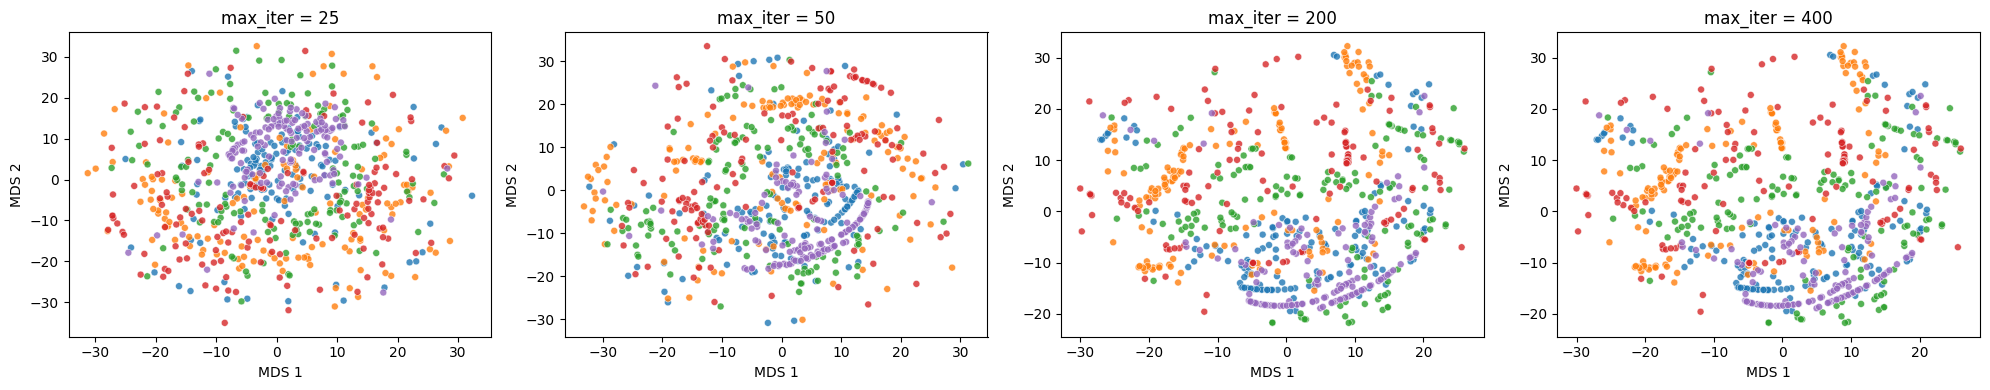

,max_iter,ca_continuity,ca_trustworthiness,knn_accuracy,best_k
0,25,0.033771,0.032750,0.449973,11
1,50,0.037181,0.035857,0.514240,7
2,200,0.039343,0.038032,0.598667,5
3,400,0.039343,0.038032,0.598667,5


In [22]:
mds_max_iter_results = plot_mds_param(
    param_name="max_iter",
    param_values=default_mds_hyperparams["max_iter"],
    distance_matrix=dist_mat,
    original_data=original_data,
    labels=labels
)

mds_max_iter_results

eps = 0.001 | CA Cont 0.0385 | CA Trust 0.0367 | KNN 0.563 | Geriausias k KNN 9
eps = 0.0001 | CA Cont 0.0392 | CA Trust 0.0375 | KNN 0.576 | Geriausias k KNN 5
eps = 1e-05 | CA Cont 0.0393 | CA Trust 0.0378 | KNN 0.583 | Geriausias k KNN 6
eps = 1e-06 | CA Cont 0.0393 | CA Trust 0.0380 | KNN 0.599 | Geriausias k KNN 5


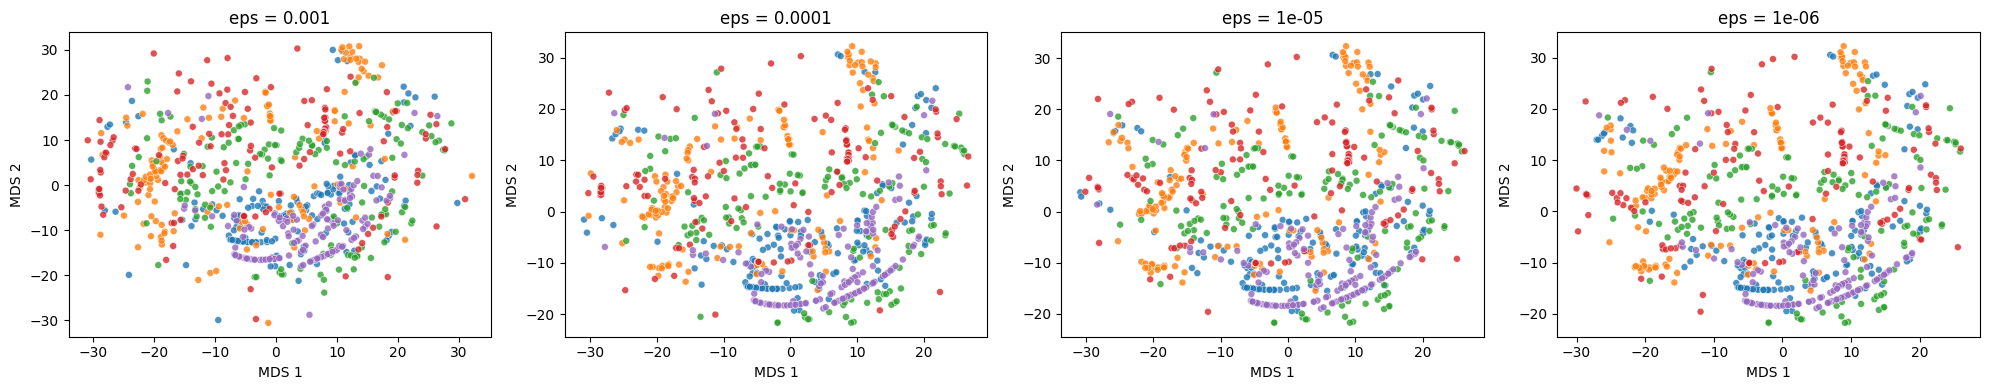

,eps,ca_continuity,ca_trustworthiness,knn_accuracy,best_k
0,0.001000,0.038454,0.036679,0.562933,9
1,0.000100,0.039180,0.037495,0.575787,5
2,0.000010,0.039292,0.037785,0.583360,6
3,0.000001,0.039343,0.038032,0.598667,5


In [23]:
mds_eps_results = plot_mds_param(
    param_name="eps",
    param_values=default_mds_hyperparams["eps"],
    distance_matrix=dist_mat,
    original_data=original_data,
    labels=labels
)

mds_eps_results

## t-SNE tyrimas

In [4]:
def plot_tsne(data, perplexity=0.1, early_exaggeration=100, ax=None):
    embeddings = TSNE(perplexity=perplexity, early_exaggeration=early_exaggeration)\
        .fit_transform(data)
    
    if ax is None:
        ax = plt.gca()

    print(embeddings[:, 0].shape, embeddings[:, 1].shape)
    sns.scatterplot(x=embeddings[:, 0], y=embeddings[:, 1], ax=ax, hue=labels) #, s=25, alpha=0.8, hue=labels, palette='bright', ax=ax)

In [5]:
from itertools import product

In [6]:
default_tsne_hyperparams = {
    "perplexity":         [5, 50, 200],
    "max_iter":             [250, 500, 2000],
    "early_exaggeration": [4.0, 12.0, 24.0],
    "learning_rate":      [10, 100, 1000],
}

keys = list(default_tsne_hyperparams.keys())
values = list(default_tsne_hyperparams.values())

In [ ]:
results = []

for combo in product(*values):
    params = dict(zip(keys, combo))

    embedding = TSNE(
        perplexity         = params["perplexity"],
        max_iter           = params["max_iter"],
        early_exaggeration = params["early_exaggeration"],
        learning_rate      = params["learning_rate"],
        metric             = "precomputed",
        init               = "random",
        random_state       = 42,
    ).fit_transform(dist_mat)

    original_flat = original_data.reshape(len(original_data), -1)

    trust_scores = []
    cont_scores = []
    knn_scores = []

    for k in range(5, 30):
        ca_tc = class_aware_trustworthiness_continuity.measure(
            original_flat,
            embedding,
            label=labels,
            k=k
        )

        trust_scores.append(
            ca_tc["ca_trustworthiness"] / 25
        )
        cont_scores.append(
            ca_tc["ca_continuity"] / 25
        )

        knn = KNeighborsClassifier(n_neighbors=k)
        knn_scores.append(
            cross_val_score(knn, embedding, labels, cv=5).mean()
        )

    trust_score = np.mean(trust_scores)
    cont_score = np.mean(cont_scores)
    knn_score = np.mean(knn_scores)
    best_k = np.argmax(knn_scores) + 5

    results.append({
        **params,
        "ca_trustworhiness": trust_score,
        'ca_continuity': cont_score,
        "embedding": embedding
    })

In [18]:
def plot_tsne_param(param_name, param_values, distance_matrix, labels=None, random_state=42):
    n = len(param_values)
    cols = min(n, 4)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for i, val in enumerate(param_values):
        params = {param_name: val}

        max_iter = 1000 if param_name != 'max_iter' else val
        perplexity = 50 if param_name != 'perplexity' else val

        if param_name in ['max_iter', 'perplexity']:
            tsne = TSNE(
                n_components=2,
                metric="precomputed",
                random_state=random_state,
                max_iter=max_iter,
                perplexity=perplexity,
                init="random",
            )

        elif param_name == 'max_iter':
            tsne = TSNE(
                n_components=2,
                metric="precomputed",
                random_state=random_state,
                perplexity=perplexity,
                init="random",
                **params
            )

        elif param_name == 'perplexity':
            tsne = TSNE(
                n_components=2,
                metric="precomputed",
                random_state=random_state,
                max_iter=max_iter,
                init="random",
                **params
            )

        else:
            tsne = TSNE(
                n_components=2,
                metric="precomputed",
                random_state=random_state,
                init="random",
                **params
            )

        embedding = tsne.fit_transform(distance_matrix)

        ax = axes[i]
        original_flat = original_data.reshape(len(original_data), -1)
        
        trust_scores = []
        cont_scores = []
        knn_scores = []

        for k in range(5, 30):
            ca_tc = class_aware_trustworthiness_continuity.measure(
                original_flat,
                embedding,
                label=labels,
                k=k
            )

            trust_scores.append(
                ca_tc["ca_trustworthiness"]
            )
            cont_scores.append(
                ca_tc["ca_continuity"]
            )

            knn = KNeighborsClassifier(n_neighbors=k)
            knn_scores.append(
                cross_val_score(knn, embedding, labels, cv=5).mean()
            )

        trust_score = np.mean(trust_scores)
        cont_score = np.mean(cont_scores)
        knn_score = np.mean(knn_scores)
        best_k = np.argmax(knn_scores) + 5

        print(
            "Value:", val,
            "CA Continuity", cont_score,
            "CA Trustworthiness", trust_score,
            "KNN", knn_score,
            "Geriausias k KNN", best_k
        )

        if labels is not None:
            sns.scatterplot(
                x=embedding[:, 0],
                y=embedding[:, 1],
                hue=labels,
                palette="tab10",
                ax=ax,
                legend=False
            )
        else:
            ax.scatter(embedding[:, 0], embedding[:, 1])

        ax.set_title(f"{param_name} = {val}")
        ax.set_xlabel("t-SNE 1")
        ax.set_ylabel("t-SNE 2")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

Value: 5 CA Continuity 0.9814010168954995 CA Trustworthiness 0.9798998740209375 KNN 0.6604800000000001 Geriausias k KNN 5
Value: 50 CA Continuity 0.9934172587755878 CA Trustworthiness 0.9909562919585944 KNN 0.6227733333333333 Geriausias k KNN 5
Value: 200 CA Continuity 0.9934689691988237 CA Trustworthiness 0.9865498737301326 KNN 0.6025066666666666 Geriausias k KNN 5


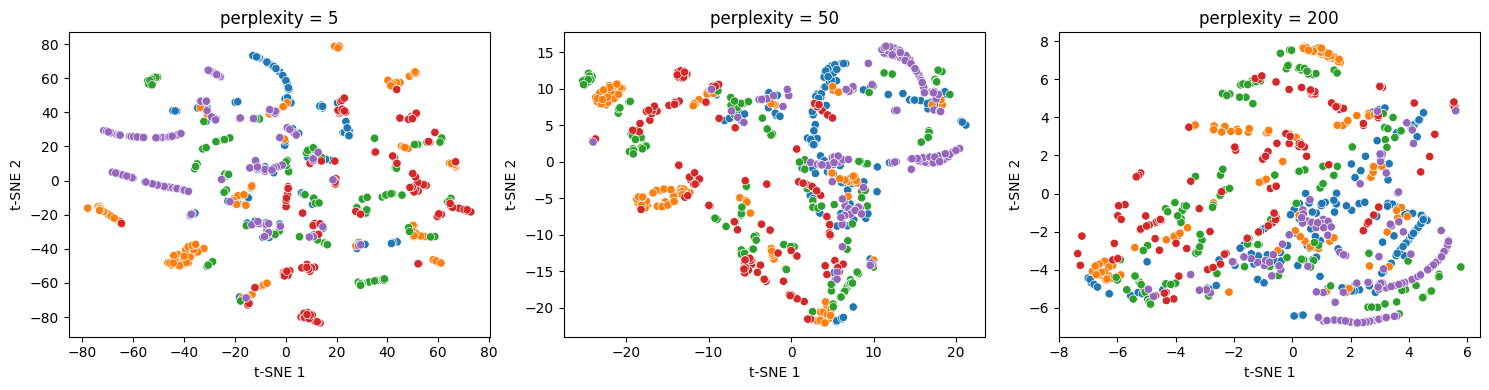

In [19]:
plot_tsne_param(
    param_name="perplexity",
    param_values=default_tsne_hyperparams['perplexity'],
    distance_matrix=dist_mat,
    labels=labels
)

Value: 250 CA Continuity 0.9902317769807708 CA Trustworthiness 0.9510355972639293 KNN 0.5996266666666666 Geriausias k KNN 6
Value: 500 CA Continuity 0.9935165031368385 CA Trustworthiness 0.9896567504763147 KNN 0.6206933333333333 Geriausias k KNN 5
Value: 2000 CA Continuity 0.9933506009951496 CA Trustworthiness 0.9911170973143 KNN 0.62224 Geriausias k KNN 5


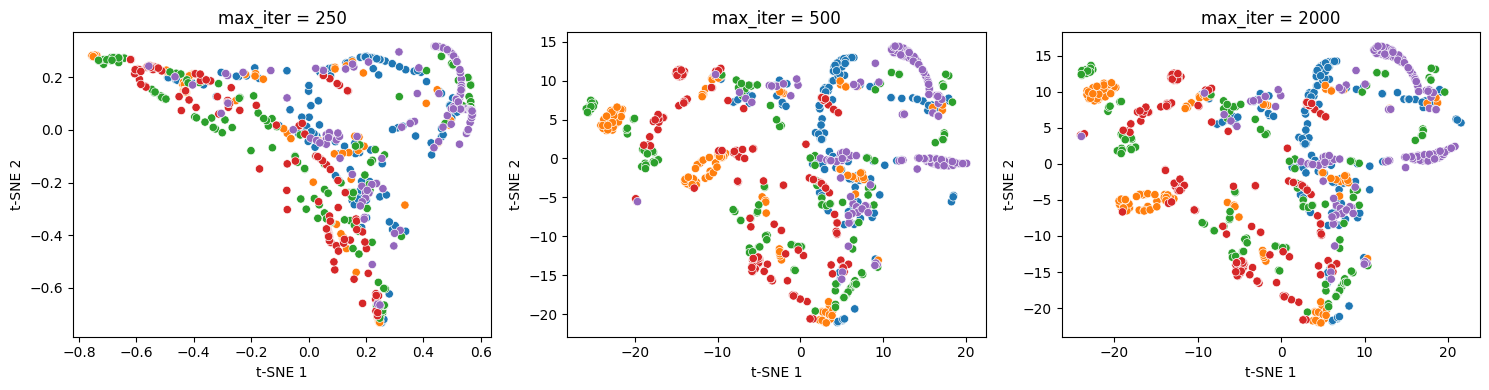

In [20]:
plot_tsne_param(
    param_name="max_iter",
    param_values=default_tsne_hyperparams['max_iter'],
    distance_matrix=dist_mat,
    labels=labels
)

In [ ]:
plot_tsne_param(
    param_name="early_exaggeration",
    param_values=default_tsne_hyperparams['early_exaggeration'],
    distance_matrix=dist_mat,
    labels=labels
)

Value: 4.0 CA Continuity 0.9912616267427786 CA Trustworthiness 0.9914810274883264 KNN 0.6343466666666667 Geriausias k KNN 5


Value: 10 CA Continuity 0.9931891616870068 CA Trustworthiness 0.9921046713580404 KNN 0.7600000000000001 Geriausias k KNN 5
Value: 100 CA Continuity 0.9932639129774009 CA Trustworthiness 0.9920718909419028 KNN 0.7573333333333331 Geriausias k KNN 5
Value: 1000 CA Continuity 0.9926562972065145 CA Trustworthiness 0.9903141649390961 KNN 0.7653333333333333 Geriausias k KNN 5


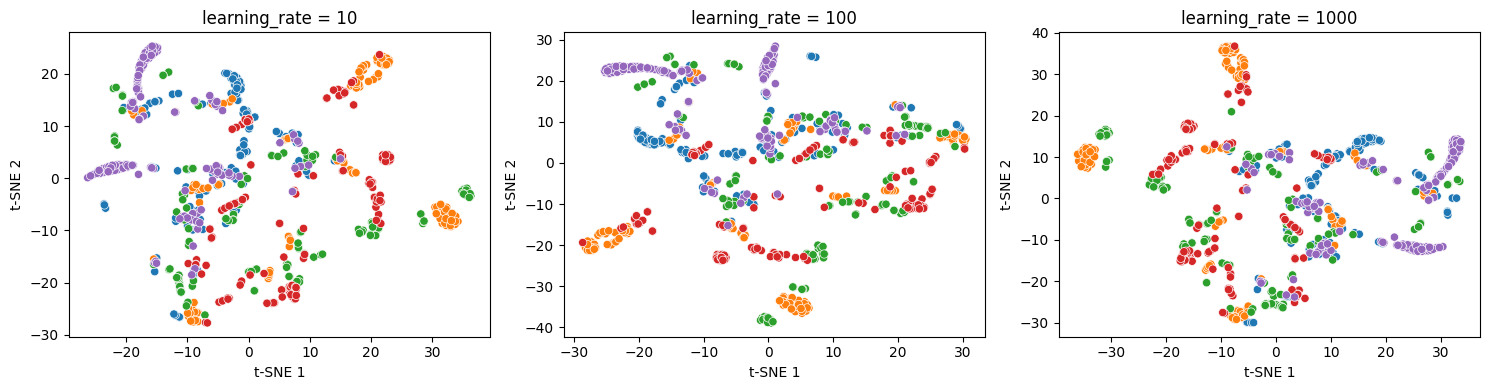

In [ ]:
plot_tsne_param(
    param_name="learning_rate",
    param_values=default_tsne_hyperparams['learning_rate'],
    distance_matrix=dist_mat,
    labels=labels
)

## UMAP tyrimas

In [ ]:
def plot_umap(
    data,
    min_dist=0.01,
    n_neighbors=20,
    n_epochs=None,
    learning_rate=1.0,
    ax=None,
    var="min_dist"
):

    embedding = UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_epochs=n_epochs,
        learning_rate=learning_rate,
        metric="precomputed",
        random_state=1
    ).fit_transform(data)

    if ax is None:
        ax = plt.gca()

    sns.scatterplot(
        x=embedding[:, 0],
        y=embedding[:, 1],
        hue=labels,
        palette="tab10",
        s=25,
        alpha=0.8,
        legend=False,
        ax=ax
    )

    ax.set_title(f"{var}={locals()[var]}")

    original_flat = original_data.reshape(len(original_data), -1)

    trust_scores = []
    cont_scores = []
    knn_scores = []

    for k in range(5, 30):
        ca_tc = class_aware_trustworthiness_continuity.measure(
            original_flat,
            embedding,
            label=labels,
            k=k
        )

        trust_scores.append(
            ca_tc["ca_trustworthiness"] / 25
        )
        cont_scores.append(
            ca_tc["ca_continuity"] / 25
        )

        knn = KNeighborsClassifier(n_neighbors=k)
        knn_scores.append(
            cross_val_score(knn, embedding, labels, cv=5).mean()
        )

    trust_score = np.mean(trust_scores)
    cont_score = np.mean(cont_scores)
    knn_score = np.mean(knn_scores)
    best_k = np.argmax(knn_scores) + 5

    print(
        f"{var}={locals()[var]} | "
        f"CA Cont {cont_score:.4f} | "
        f"CA Trust {trust_score:.4f} | "
        f"KNN {knn_score:.3f} | "
        f"Geriausias k KNN {best_k} |"
    )

/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


min_dist=0.1 | CA Cont 0.9900 | CA Trust 0.9880 | KNN 0.667 | Sil -0.024 | CH 80.1 | DB 3.671


/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


min_dist=0.001 | CA Cont 0.9887 | CA Trust 0.9879 | KNN 0.668 | Sil -0.043 | CH 62.0 | DB 4.621


/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


min_dist=0.0001 | CA Cont 0.9881 | CA Trust 0.9883 | KNN 0.680 | Sil -0.033 | CH 64.2 | DB 4.129


/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


min_dist=1e-05 | CA Cont 0.9869 | CA Trust 0.9879 | KNN 0.667 | Sil -0.062 | CH 61.2 | DB 4.202


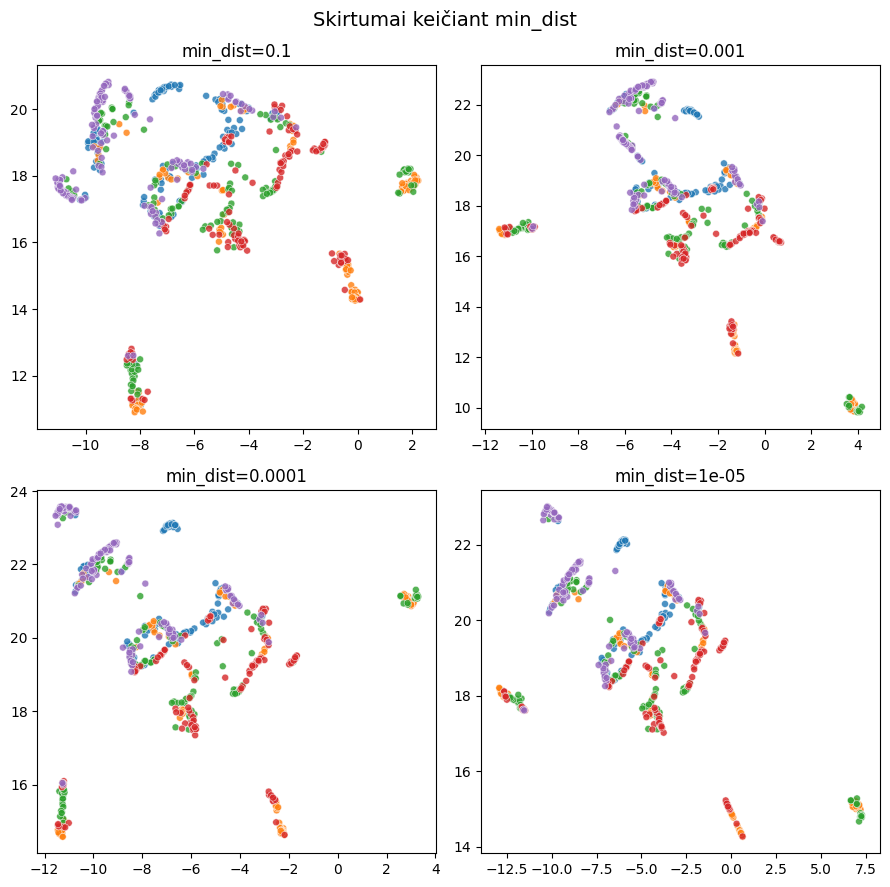

In [ ]:
min_distances = [0.1, 0.001, 0.0001, 0.00001]


fig, axs = plt.subplots(2, 2, figsize=(9, 9))
axs = axs.flatten()

fig.suptitle('Skirtumai keičiant min_dist', fontsize=14)

for i, n in enumerate(min_distances):
    plot_umap(data=dist_mat, min_dist=n, ax=axs[i], var='min_dist')

plt.tight_layout()
plt.show()

/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


n_neighbors=5 | CA Cont 0.9486 | CA Trust 0.9575 | KNN 0.744 | Sil -0.065 | CH 35.4 | DB 4.898


/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


n_neighbors=10 | CA Cont 0.9814 | CA Trust 0.9886 | KNN 0.721 | Sil -0.069 | CH 56.6 | DB 3.985


/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


n_neighbors=20 | CA Cont 0.9887 | CA Trust 0.9879 | KNN 0.667 | Sil -0.030 | CH 79.1 | DB 3.789


/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


n_neighbors=50 | CA Cont 0.9847 | CA Trust 0.9765 | KNN 0.652 | Sil -0.040 | CH 71.0 | DB 6.485


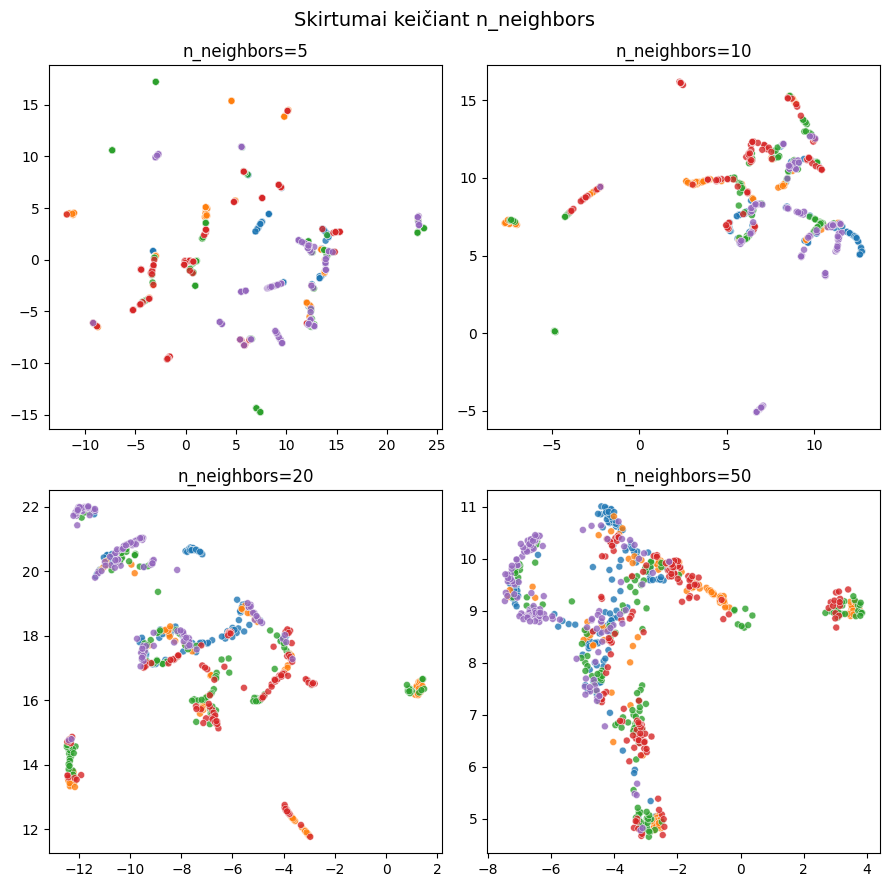

In [ ]:
neighbors = [5, 10, 20, 50]

fig, axs = plt.subplots(2, 2, figsize=(9, 9))
axs = axs.flatten()

fig.suptitle('Skirtumai keičiant n_neighbors', fontsize=14)

for i, n in enumerate(neighbors):
    plot_umap(data=dist_mat, n_neighbors=n, ax=axs[i], var='n_neighbors')

plt.tight_layout()
plt.show()

/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


n_epochs=25 | CA Cont 0.9878 | CA Trust 0.9833 | KNN 0.644 | Sil -0.030 | CH 55.3 | DB 5.759


/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


n_epochs=50 | CA Cont 0.9895 | CA Trust 0.9856 | KNN 0.693 | Sil -0.038 | CH 53.5 | DB 4.281


/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


n_epochs=100 | CA Cont 0.9896 | CA Trust 0.9857 | KNN 0.657 | Sil -0.043 | CH 55.2 | DB 4.538


/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


n_epochs=300 | CA Cont 0.9887 | CA Trust 0.9882 | KNN 0.644 | Sil -0.037 | CH 64.9 | DB 4.264


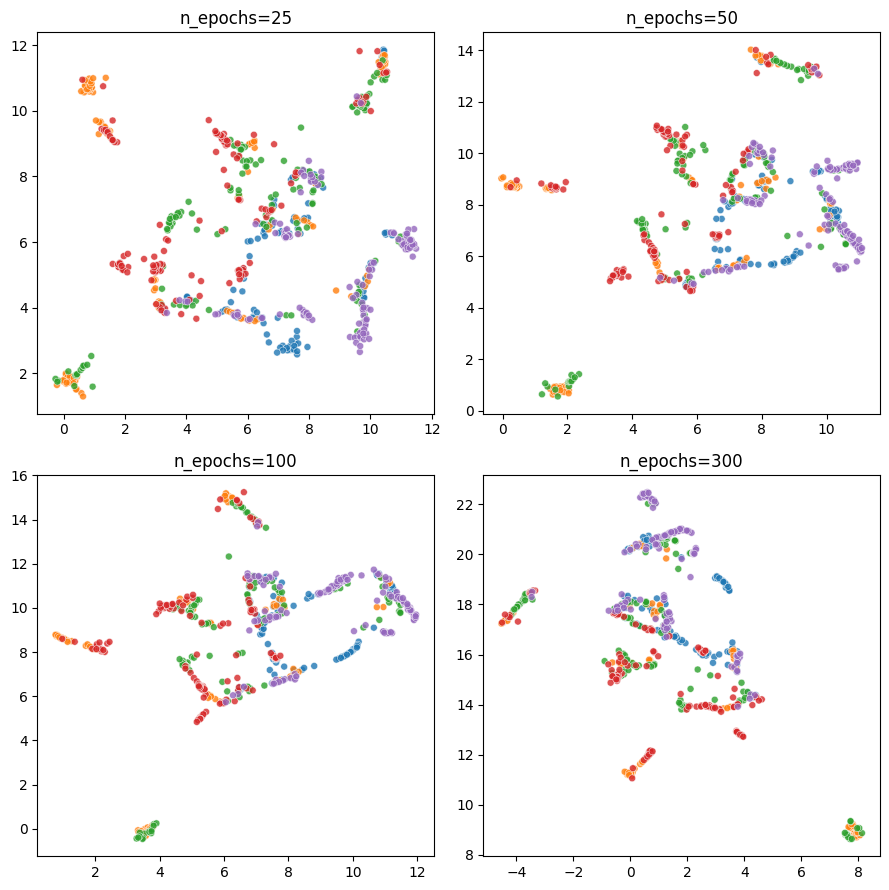

In [53]:
epochs = [25, 50, 100, 300]

fig, axs = plt.subplots(2, 2, figsize=(9, 9))
axs = axs.flatten()

for i, e in enumerate(epochs):
    plot_umap(data=dist_mat, n_epochs=e, ax=axs[i], var="n_epochs")

plt.tight_layout()
plt.show()

/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


learning_rate=1.0 | CA Cont 0.9887 | CA Trust 0.9879 | KNN 0.667 | Sil -0.030 | CH 79.1 | DB 3.789


/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


learning_rate=5.0 | CA Cont 0.9893 | CA Trust 0.9864 | KNN 0.664 | Sil -0.038 | CH 61.4 | DB 4.841


/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


learning_rate=10 | CA Cont 0.9894 | CA Trust 0.9855 | KNN 0.649 | Sil -0.044 | CH 65.7 | DB 4.259


/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


learning_rate=15 | CA Cont 0.9874 | CA Trust 0.9835 | KNN 0.639 | Sil -0.039 | CH 71.7 | DB 4.343


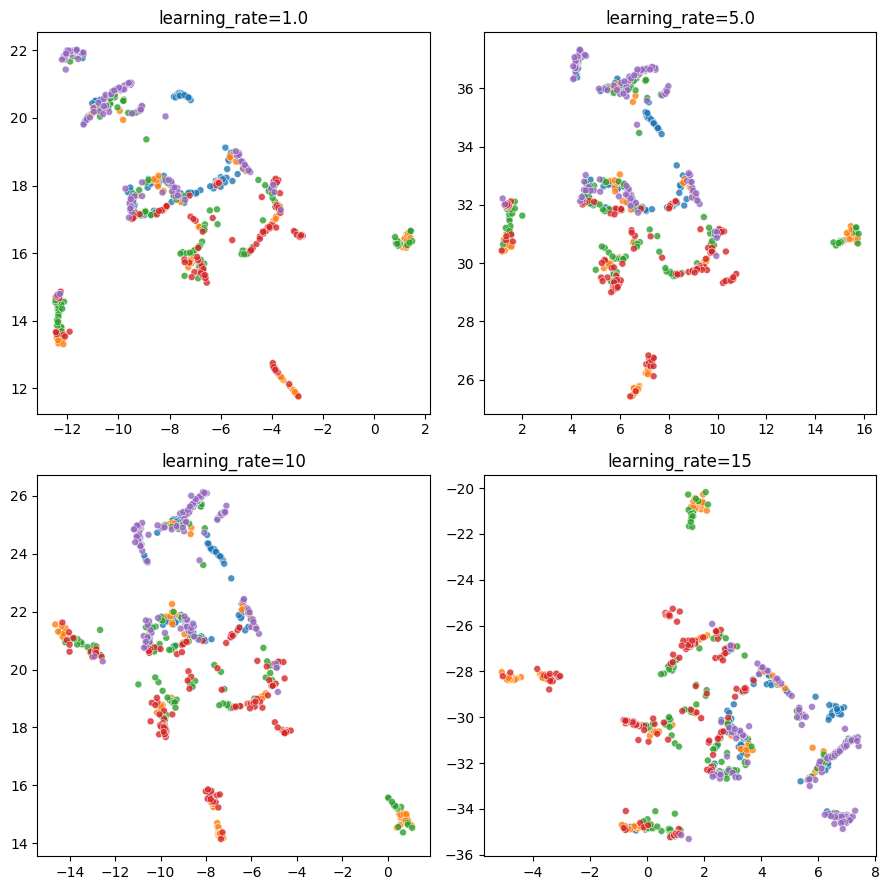

In [55]:
rates = [1.0, 5.0, 10, 15]

fig, axs = plt.subplots(2, 2, figsize=(9, 9))
axs = axs.flatten()

for i, r in enumerate(rates):
    plot_umap(data=dist_mat, learning_rate=r, ax=axs[i], var="learning_rate")

plt.tight_layout()
plt.show()

In [58]:
def search_umap_params(
    distance_matrix,
    labels,
    n_neighbors_list,
    min_dist_list,
    n_epochs_list,
    learning_rate_list,
    random_state=42
):

    results = []

    original_flat = original_data.reshape(len(original_data), -1)

    for nn in n_neighbors_list:
        for md in min_dist_list:
            for ne in n_epochs_list:
                for lr in learning_rate_list:

                    print(f"Testing: neighbors={nn}, min_dist={md}, epochs={ne}, lr={lr}")

                    umap_model = UMAP(
                        n_neighbors=nn,
                        min_dist=md,
                        n_epochs=ne,
                        learning_rate=lr,
                        metric="precomputed",
                        random_state=random_state
                    )

                    embedding = umap_model.fit_transform(distance_matrix)

                    # ----- CA Trustworthiness / Continuity -----
                    trust_score = 0
                    cont_score = 0

                    for k in range(5, 30):
                        ca_tc = class_aware_trustworthiness_continuity.measure(
                            original_flat,
                            embedding,
                            label=labels,
                            k=k
                        )

                        trust_score += ca_tc["ca_trustworthiness"] / 25
                        cont_score += ca_tc["ca_continuity"] / 25

                    # ----- KNN accuracy -----
                    knn = KNeighborsClassifier(n_neighbors=5)
                    knn_acc = cross_val_score(knn, embedding, labels, cv=5).mean()

                    # ----- clustering metrics -----
                    sil = silhouette_score(embedding, labels)
                    ch = calinski_harabasz_score(embedding, labels)
                    db = davies_bouldin_score(embedding, labels)

                    results.append({
                        "n_neighbors": nn,
                        "min_dist": md,
                        "n_epochs": ne,
                        "learning_rate": lr,
                        "ca_trustworthiness": trust_score,
                        "ca_continuity": cont_score,
                        "knn_accuracy": knn_acc,
                        "silhouette": sil,
                        "calinski_harabasz": ch,
                        "davies_bouldin": db
                    })

    df = pd.DataFrame(results)

    # ranking score (higher better, except DB)
    df["score"] = (
        df["knn_accuracy"]
        + df["silhouette"]
        + df["ca_trustworthiness"]
        + df["ca_continuity"]
        + (df["calinski_harabasz"] / df["calinski_harabasz"].max())
        - df["davies_bouldin"]
    )

    best = df.sort_values("score", ascending=False).iloc[0]

    return df, best

In [64]:
min_dists = [0.001, 0.01]
neighbors = [10, 20, 50]
epochs = [25, 50, 100]
rates = [1.0, 5.0, 10]

results_df, best_params = search_umap_params(
    dist_mat,
    labels,
    neighbors,
    min_dists,
    epochs,
    rates
)

print("\nBEST CONFIGURATION:")
print(best_params)

Testing: neighbors=10, min_dist=0.001, epochs=25, lr=1.0


/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Testing: neighbors=10, min_dist=0.001, epochs=25, lr=5.0


/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Testing: neighbors=10, min_dist=0.001, epochs=25, lr=10


...

Testing: neighbors=50, min_dist=0.01, epochs=100, lr=5.0


/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Testing: neighbors=50, min_dist=0.01, epochs=100, lr=10


/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



BEST CONFIGURATION:
n_neighbors            10.000000
min_dist                0.001000
n_epochs              100.000000
learning_rate          10.000000
ca_trustworthiness      0.976784
ca_continuity           0.982065
knn_accuracy            0.677333
silhouette             -0.054516
calinski_harabasz      74.603798
davies_bouldin          3.507688
score                   0.038953
Name: 8, dtype: float64


In [40]:
class_aware_trustworthiness_continuity.measure(
    
)

TypeError: measure() missing 3 required positional arguments: 'orig', 'emb', and 'label'